# HIT140 Assessment 2 – Team Defence Performance

**Contributor:** Keke  
**Analysis component:** Team Defence Performance  
**Analysis level:** one row per team  
**Primary stage:** group stage only  
**Comparison:** teams that subsequently reached the knockout stage versus teams eliminated in the group stage

This notebook is an analysis of team defensive performance in the group stage. It is based on the data from two sources, records the data preparation procedures, calculates team-level variables, verifies the basic conditions for comparing two groups, and provides descriptive statistics, a confidence interval and a two-sample t-test.

## 1. Analytic question formulation

**Analytic question**

> During the group stage, was mean goals conceded per match different between teams that subsequently reached the knockout stage and teams eliminated in the group stage?

I use only defensive performance from the group stage, before the knockout rounds. This keeps later matches out of the comparison.

**Purpose:** the analysis examines whether early tournament defensive performance is associated with later progression.

**Scope:** this analysis focuses on team-level defensive performance rather than player-level goalkeeping measures.

### Population, sample, variables and hypotheses

- **Target population for this analysis:** team performances in the 2026 FIFA World Cup.
- **Sample:** all 48 participating teams with complete FIFA and FBref records. This is the full set of teams in this tournament.
- **Observational unit:** one team.
- **Primary numerical response:** `Group-stage Goals Conceded per Match`.
- **Grouping variable:** `Progression Group` (`Knockout` or `Group-stage Eliminated`).
- **Parameter $\mu_K$:** mean group-stage goals conceded per match for knockout-stage teams.
- **Parameter $\mu_E$:** mean group-stage goals conceded per match for group-stage-eliminated teams.

I set the following two-sided hypotheses before running the statistical test:

$$H_0: \mu_K - \mu_E = 0$$

$$H_a: \mu_K - \mu_E \neq 0$$

The significance level is $\alpha=0.05$.

## 2. Data acquisition, wrangling and preparation

**Raw sources**

1. FIFA team statistics: https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/team-statistics?group=gct_goalkeeping&stat=goals_conceded
2. FBref Scores & Fixtures: https://fbref.com/en/comps/1/schedule/World-Cup-Scores-and-Fixtures

FIFA provides team goals conceded and clean sheets. FBref provides match, round and score information. I cleaned both sources and matched them by team name.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

RANDOM_SEED = 140
DATA_DIR = Path('data')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

FIFA_RAW_FILE = DATA_DIR / 'defence.xlsx'
FBREF_RAW_FILE = DATA_DIR / 'fbref_world_cup_2026_scores_fixtures_raw.txt'
FINAL_DATA_FILE = DATA_DIR / 'keke_defence_final_dataset.xlsx'

### 2.1 Wrangle the copied FIFA table

The downloaded FIFA workbook contains alternating statistics rows and team-name rows because merged website cells were copied into Excel. Below is the code which joins these rows without altering the raw file.

In [2]:
fifa_raw = pd.read_excel(FIFA_RAW_FILE)

fifa_stats = (
    fifa_raw.loc[
        fifa_raw['Team'].isna() & fifa_raw['Goals Conceded'].notna(),
        ['Rank', 'Clean Sheets', 'Goals Conceded']
    ]
    .reset_index(drop=True)
)
fifa_teams = (
    fifa_raw.loc[fifa_raw['Team'].notna(), ['Team']]
    .reset_index(drop=True)
)

assert len(fifa_stats) == len(fifa_teams) == 48
fifa_clean = pd.concat([fifa_teams, fifa_stats], axis=1)
fifa_clean[['Rank', 'Clean Sheets', 'Goals Conceded']] = (
    fifa_clean[['Rank', 'Clean Sheets', 'Goals Conceded']].astype(int)
)
fifa_clean.head()

,Team,Rank,Clean Sheets,Goals Conceded
0,Iraq,1,0,12
1,Tunisia,1,0,12
2,England,1,2,12
3,Uzbekistan,4,0,11
4,Norway,4,0,11


### 2.2 Wrangle the FBref fixture file

Blank separator rows are deleted, country codes are deleted from team labels, a shortened Bosnia and Herzegovina label is standardised, and regulation/extra-time scores are extracted, and the penalty shootout score is not treated as a match goal.

In [3]:
fbref_raw = pd.read_csv(FBREF_RAW_FILE)
fbref_matches = fbref_raw.loc[
    fbref_raw['Score'].notna() & fbref_raw['Score'].astype(str).str.strip().ne('')
].copy()

def normalise_team_name(value):
    text = str(value).strip()
    parts = text.split()
    if len(parts) > 1 and len(parts[0]) in (2, 3) and parts[0].islower():
        text = ' '.join(parts[1:])
    parts = text.split()
    if len(parts) > 1 and len(parts[-1]) in (2, 3) and parts[-1].islower():
        text = ' '.join(parts[:-1])
    return {'Bosnia–Herz': 'Bosnia and Herzegovina'}.get(text, text)

def parse_score(value):
    text = str(value)
    while '(' in text and ')' in text:
        left = text.index('(')
        right = text.index(')', left)
        text = text[:left] + text[right + 1:]
    home_goals, away_goals = text.replace('–', '-').split('-')
    return int(home_goals.strip()), int(away_goals.strip())

cleaned_matches = []
for match_number, (_, match) in enumerate(fbref_matches.iterrows(), start=1):
    home_goals, away_goals = parse_score(match['Score'])
    cleaned_matches.append({
        'Match ID': f'M{match_number:03d}',
        'Round': match['Round'],
        'Week': match['Wk'],
        'Date': match['Date'],
        'Home Team': normalise_team_name(match['Home']),
        'Home Goals': home_goals,
        'Away Team': normalise_team_name(match['Away']),
        'Away Goals': away_goals,
        'Venue': match['Venue'],
        'Notes': match['Notes'],
    })

matches = pd.DataFrame(cleaned_matches)
print(f'Completed matches retained: {len(matches)}')
matches.head()

Completed matches retained: 104


,Match ID,Round,Week,Date,Home Team,Home Goals,Away Team,Away Goals,Venue,Notes
0,M001,Group stage,1.0,2026-06-11,Mexico,2,South Africa,0,Estadio Banorte (Neutral Site),NaN
1,M002,Group stage,1.0,2026-06-11,Korea Republic,2,Czechia,1,Estadio Akron (Neutral Site),NaN
2,M003,Group stage,1.0,2026-06-12,Canada,1,Bosnia and Herzegovina,1,BMO Field (Neutral Site),NaN
3,M004,Group stage,1.0,2026-06-12,USA,4,Paraguay,1,SoFi Stadium (Neutral Site),NaN
4,M005,Group stage,1.0,2026-06-13,Qatar,1,Switzerland,1,Levi's Stadium (Neutral Site),NaN


### 2.3 Reshape matches into team–match records

I created 104 team–match records for each of the 104 matches. This table is used in the preparation process. I merged all of the records into one record per team for the t-test, to prevent multiple matches from being treated as separate teams.

In [4]:
team_match_records = []
for _, match in matches.iterrows():
    team_match_records.extend([
        {
            'Match ID': match['Match ID'],
            'Round': match['Round'],
            'Date': match['Date'],
            'Team': match['Home Team'],
            'Opponent': match['Away Team'],
            'Location': 'Home designation',
            'Goals For': match['Home Goals'],
            'Goals Conceded': match['Away Goals'],
            'Clean Sheet': int(match['Away Goals'] == 0),
        },
        {
            'Match ID': match['Match ID'],
            'Round': match['Round'],
            'Date': match['Date'],
            'Team': match['Away Team'],
            'Opponent': match['Home Team'],
            'Location': 'Away designation',
            'Goals For': match['Away Goals'],
            'Goals Conceded': match['Home Goals'],
            'Clean Sheet': int(match['Home Goals'] == 0),
        },
    ])

team_matches = pd.DataFrame(team_match_records)
assert len(team_matches) == 208
team_matches.head()

,Match ID,Round,Date,Team,Opponent,Location,Goals For,Goals Conceded,Clean Sheet
0,M001,Group stage,2026-06-11,Mexico,South Africa,Home designation,2,0,1
1,M001,Group stage,2026-06-11,South Africa,Mexico,Away designation,0,2,0
2,M002,Group stage,2026-06-11,Korea Republic,Czechia,Home designation,2,1,0
3,M002,Group stage,2026-06-11,Czechia,Korea Republic,Away designation,1,2,0
4,M003,Group stage,2026-06-12,Canada,Bosnia and Herzegovina,Home designation,1,1,0


### 2.4 Cross-source validation and derived variables

I added the goals conceded by the team (from FBref) and compared with the goals conceded from FIFA. Identification of progression: If a team showed up in a later round, it was considered to be progressed. I then worked out the primary result without taking into account group-stage results.

In [5]:
tournament_summary = (
    team_matches.groupby('Team')
    .agg(
        **{
            'Tournament Matches Played': ('Match ID', 'size'),
            'FBref Tournament Goals Conceded': ('Goals Conceded', 'sum'),
            'Reached Knockout': ('Round', lambda rounds: (rounds != 'Group stage').any()),
        }
    )
    .reset_index()
)

validation = fifa_clean.merge(
    tournament_summary,
    on='Team',
    how='outer',
    indicator=True,
    validate='one_to_one'
)
assert validation['_merge'].eq('both').all()
assert (validation['Goals Conceded'] == validation['FBref Tournament Goals Conceded']).all()
assert validation['Goals Conceded'].sum() == 308

group_stage_team_matches = team_matches.loc[
    team_matches['Round'].eq('Group stage')
].copy()
assert len(group_stage_team_matches) == 144

analysis_df = (
    group_stage_team_matches.groupby('Team')
    .agg(
        **{
            'Group-stage Matches': ('Match ID', 'size'),
            'Group-stage Goals For': ('Goals For', 'sum'),
            'Group-stage Goals Conceded': ('Goals Conceded', 'sum'),
            'Group-stage Clean Sheets': ('Clean Sheet', 'sum'),
        }
    )
    .reset_index()
    .merge(
        validation[[
            'Team', 'Reached Knockout', 'Tournament Matches Played',
            'Goals Conceded', 'Clean Sheets', 'Rank'
        ]],
        on='Team',
        how='inner',
        validate='one_to_one'
    )
)

analysis_df['Progression Group'] = np.where(
    analysis_df['Reached Knockout'],
    'Knockout',
    'Group-stage Eliminated'
)
analysis_df['Group-stage Goals Conceded per Match'] = (
    analysis_df['Group-stage Goals Conceded'] / analysis_df['Group-stage Matches']
)
analysis_df['Group-stage Clean Sheet Rate'] = (
    analysis_df['Group-stage Clean Sheets'] / analysis_df['Group-stage Matches']
)
analysis_df['Group-stage Goal Difference per Match'] = (
    (analysis_df['Group-stage Goals For'] - analysis_df['Group-stage Goals Conceded'])
    / analysis_df['Group-stage Matches']
)

analysis_df = analysis_df.rename(columns={
    'Goals Conceded': 'Tournament Goals Conceded (FIFA)',
    'Clean Sheets': 'Tournament Clean Sheets (FIFA)',
    'Rank': 'FIFA Rank by Goals Conceded',
})
analysis_df = analysis_df[[
    'Team', 'Progression Group', 'Group-stage Matches',
    'Group-stage Goals For', 'Group-stage Goals Conceded',
    'Group-stage Clean Sheets', 'Group-stage Goals Conceded per Match',
    'Group-stage Clean Sheet Rate', 'Group-stage Goal Difference per Match',
    'Tournament Matches Played', 'Tournament Goals Conceded (FIFA)',
    'Tournament Clean Sheets (FIFA)', 'FIFA Rank by Goals Conceded'
]].sort_values('Team').reset_index(drop=True)

assert len(analysis_df) == 48
assert analysis_df['Group-stage Matches'].eq(3).all()
analysis_df.head()

,Team,Progression Group,Group-stage Matches,Group-stage Goals For,Group-stage Goals Conceded,Group-stage Clean Sheets,Group-stage Goals Conceded per Match,Group-stage Clean Sheet Rate,Group-stage Goal Difference per Match,Tournament Matches Played,Tournament Goals Conceded (FIFA),Tournament Clean Sheets (FIFA),FIFA Rank by Goals Conceded
0,Algeria,Knockout,3,5,7,0,2.333333,0.000000,-0.666667,4,9,0,10
1,Argentina,Knockout,3,8,1,2,0.333333,0.666667,2.333333,8,8,2,14
2,Australia,Knockout,3,2,2,2,0.666667,0.666667,0.000000,4,3,2,41
3,Austria,Knockout,3,6,6,0,2.000000,0.000000,0.000000,4,9,0,10
4,Belgium,Knockout,3,6,2,1,0.666667,0.333333,1.333333,6,7,1,19


### 2.5 Save the cleaned and combined dataset

Match records are cleaned and saved in one workbook in addition to FIFA team statistics and final team level analysis table. A brief description of the data is provided for use by the exported file without reference to the Notebook.

In [17]:
fifa_export = fifa_clean.rename(columns={
    'Rank': 'FIFA Rank by Goals Conceded',
    'Goals Conceded': 'Goals Conceded',
})[['Team', 'FIFA Rank by Goals Conceded', 'Clean Sheets', 'Goals Conceded']]

dataset_readme = pd.DataFrame({
    'Dataset': [
        'Final_Data',
        'FBref_Matches',
        'FIFA_Team_Data',
        'Source files',
    ],
    'Description': [
        'Team-level group-stage analysis dataset used for descriptive and inferential statistics.',
        'Cleaned match-level records from the FBref Scores & Fixtures source.',
        'Cleaned team-level defensive statistics from the FIFA source.',
        'defence.xlsx and fbref_world_cup_2026_scores_fixtures_raw.txt.',
    ],
})

with pd.ExcelWriter(FINAL_DATA_FILE, engine='openpyxl') as writer:
    analysis_df.to_excel(writer, sheet_name='Final_Data', index=False)
    matches.to_excel(writer, sheet_name='FBref_Matches', index=False)
    fifa_export.to_excel(writer, sheet_name='FIFA_Team_Data', index=False)
    dataset_readme.to_excel(writer, sheet_name='README', index=False)

print(f'Final dataset saved to: {FINAL_DATA_FILE}')
analysis_df[[
    'Team',
    'Progression Group',
    'Group-stage Matches',
    'Group-stage Goals Conceded',
    'Group-stage Goals Conceded per Match'
]].head(10)

Final dataset saved to: data\keke_defence_final_dataset.xlsx


,Team,Progression Group,Group-stage Matches,Group-stage Goals Conceded,Group-stage Goals Conceded per Match
0,Algeria,Knockout,3,7,2.333333
1,Argentina,Knockout,3,1,0.333333
2,Australia,Knockout,3,2,0.666667
3,Austria,Knockout,3,6,2.000000
4,Belgium,Knockout,3,2,0.666667
5,Bosnia and Herzegovina,Knockout,3,6,2.000000
6,Brazil,Knockout,3,1,0.333333
7,Cabo Verde,Knockout,3,2,0.666667
8,Canada,Knockout,3,3,1.000000
9,Colombia,Knockout,3,1,0.333333


## 3. Data preparation and sampling

**Eligibility rule:** the team was required to have played in both sources and had to have played at least 3 group stage matches. There were no teams removed as all 48 teams did this.

**Sampling method:** I didn't use a random subset of the 48 teams present at this tournament, I used all 48 teams. A sampling seed was not necessary. These teams are from the same tournament, so the results cannot be generalized to other tournaments.

**Independence consideration:** each team is supposed to play only one game and is a part of one group. Note, however, that the observations are not entirely independent, as the teams play each other in the same tournament.

In [7]:
sampling_report = pd.Series({
    'Teams in FIFA source': fifa_clean['Team'].nunique(),
    'Teams in FBref source': team_matches['Team'].nunique(),
    'Eligible teams retained': analysis_df['Team'].nunique(),
    'Teams excluded': 48 - analysis_df['Team'].nunique(),
    'Group-stage matches': len(matches.loc[matches['Round'].eq('Group stage')]),
    'Group-stage team-match records': len(group_stage_team_matches),
    'Knockout teams': analysis_df['Progression Group'].eq('Knockout').sum(),
    'Group-stage eliminated teams': analysis_df['Progression Group'].eq('Group-stage Eliminated').sum(),
    'Missing primary outcomes': analysis_df['Group-stage Goals Conceded per Match'].isna().sum(),
})
sampling_report

Teams in FIFA source               48
Teams in FBref source              48
Eligible teams retained            48
Teams excluded                      0
Group-stage matches                72
Group-stage team-match records    144
Knockout teams                     32
Group-stage eliminated teams       16
Missing primary outcomes            0
dtype: int64

## 4. Descriptive statistics and confidence intervals

The table shows the group sizes, means, spread, ranges and 95% confidence intervals. The two means are compared in a t-test below with a confidence interval for the difference reported.

In [8]:
outcome = 'Group-stage Goals Conceded per Match'
group = 'Progression Group'

descriptive = (
    analysis_df.groupby(group)[outcome]
    .agg(n='count', mean='mean', median='median', std='std', minimum='min', maximum='max')
)
descriptive['se'] = descriptive['std'] / np.sqrt(descriptive['n'])
descriptive['ci95_lower'] = (
    descriptive['mean']
    - stats.t.ppf(0.975, descriptive['n'] - 1) * descriptive['se']
)
descriptive['ci95_upper'] = (
    descriptive['mean']
    + stats.t.ppf(0.975, descriptive['n'] - 1) * descriptive['se']
)
descriptive.round(3)

,n,mean,median,std,minimum,maximum,se,ci95_lower,ci95_upper
Progression Group,,,,,,,,,
Group-stage Eliminated,16,2.375,2.333,1.081,1.0,4.000,0.270,1.799,2.951
Knockout,32,1.052,1.000,0.667,0.0,2.333,0.118,0.812,1.293


In [9]:
# Supporting variables add context without replacing the pre-specified primary outcome.
supporting_summary = (
    analysis_df.groupby(group)[[
        'Group-stage Clean Sheet Rate',
        'Group-stage Goal Difference per Match'
    ]]
    .agg(['mean', 'median', 'std'])
)
supporting_summary.round(3)

Group-stage Clean Sheet Rate                \
                                               mean median    std   
Progression Group                                                   
Group-stage Eliminated                        0.083  0.000  0.149   
Knockout                                      0.375  0.333  0.314   

                       Group-stage Goal Difference per Match                
                                                        mean median    std  
Progression Group                                                           
Group-stage Eliminated                                -1.708 -1.500  1.121  
Knockout                                               0.854  0.833  0.935

## 5. Visualisation

The first figure compares the distributions but keeps all of the team observations. The second figure gives the team-level values which make up the difference. Both figures are saved at a resolution of 300 dpi for easy viewing and printing.

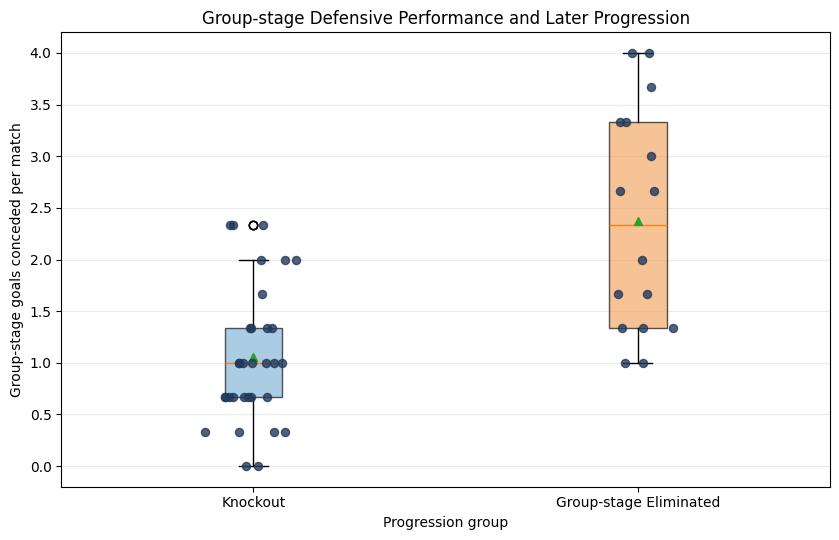

In [10]:
group_order = ['Knockout', 'Group-stage Eliminated']
group_values = [
    analysis_df.loc[analysis_df[group].eq(name), outcome].to_numpy()
    for name in group_order
]
rng = np.random.default_rng(RANDOM_SEED)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
box = ax.boxplot(group_values, tick_labels=group_order, patch_artist=True, showmeans=True)
for patch, colour in zip(box['boxes'], ['#7FB3D5', '#F0A35E']):
    patch.set_facecolor(colour)
    patch.set_alpha(0.65)
for position, values in enumerate(group_values, start=1):
    jitter = rng.normal(0, 0.045, size=len(values))
    ax.scatter(np.full(len(values), position) + jitter, values,
               color='#23395B', alpha=0.8, s=34, zorder=3)
ax.set_title('Group-stage Defensive Performance and Later Progression')
ax.set_xlabel('Progression group')
ax.set_ylabel('Group-stage goals conceded per match')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'Figure_1_Group_Stage_Defence_Boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

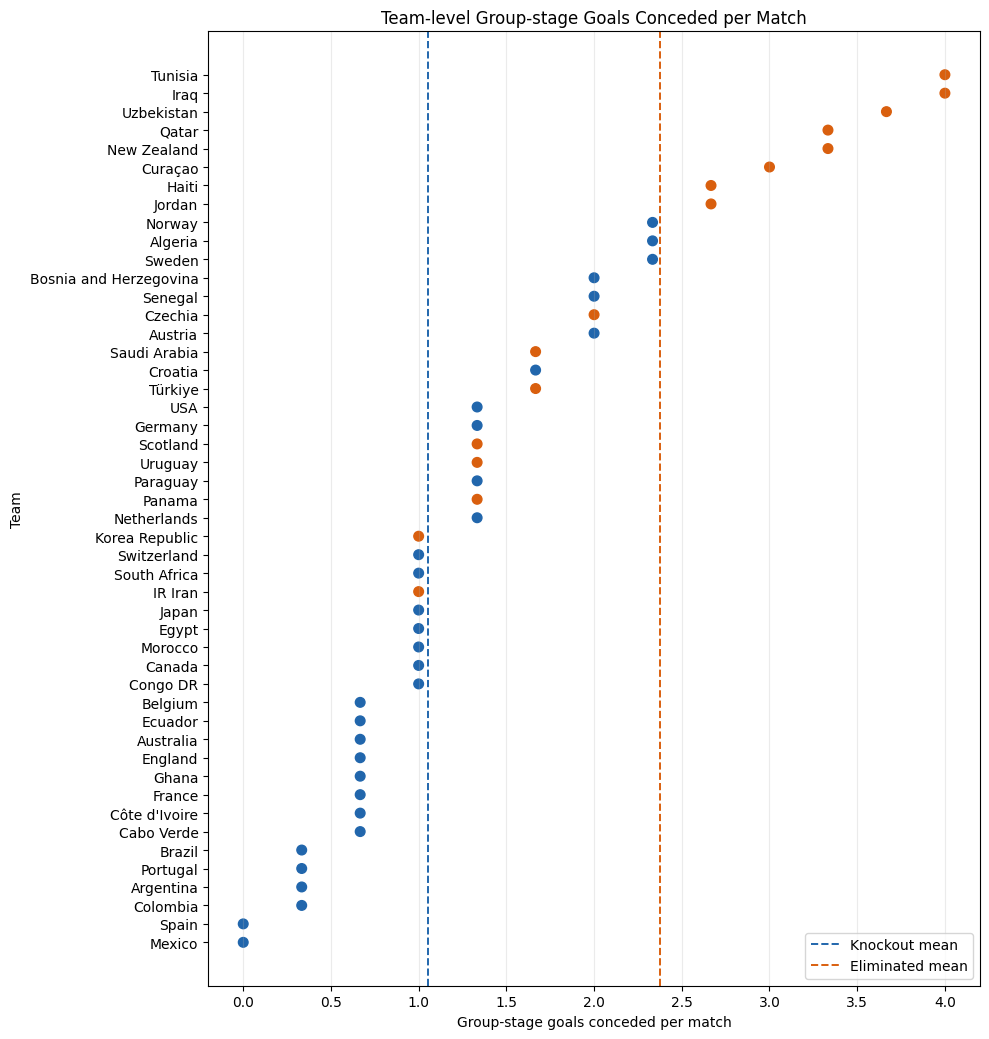

In [11]:
plot_df = analysis_df.sort_values(outcome).reset_index(drop=True)
colours = plot_df[group].map({
    'Knockout': '#2166AC',
    'Group-stage Eliminated': '#D95F0E'
})

fig, ax = plt.subplots(figsize=(10, 10.5))
ax.scatter(plot_df[outcome], plot_df['Team'], c=colours, s=48)
ax.axvline(
    analysis_df.loc[analysis_df[group].eq('Knockout'), outcome].mean(),
    color='#2166AC', linestyle='--', linewidth=1.4, label='Knockout mean'
)
ax.axvline(
    analysis_df.loc[analysis_df[group].eq('Group-stage Eliminated'), outcome].mean(),
    color='#D95F0E', linestyle='--', linewidth=1.4, label='Eliminated mean'
)
ax.set_title('Team-level Group-stage Goals Conceded per Match')
ax.set_xlabel('Group-stage goals conceded per match')
ax.set_ylabel('Team')
ax.grid(axis='x', alpha=0.25)
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'Figure_2_Team_Level_Defence.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Prepare the two groups for comparison

The dependent variable is a continuous variable, the two progression group is mutually exclusive and each team is only included in the end result. These form the simple conditions for comparisons between two samples in this analysis.

In [12]:
knockout = analysis_df.loc[analysis_df[group].eq('Knockout'), outcome].dropna()
eliminated = analysis_df.loc[
    analysis_df[group].eq('Group-stage Eliminated'), outcome
].dropna()

comparison_groups = pd.Series({
    'Knockout teams': len(knockout),
    'Group-stage eliminated teams': len(eliminated),
})
comparison_groups

Knockout teams                  32
Group-stage eliminated teams    16
dtype: int64

## 7. Inferential statistics: confidence interval and two-sample t-test

I define the difference as $\bar{x}_K-\bar{x}_E$. A negative value means that knockout teams conceded fewer goals per match. I use the standard independent two-sample t-test with equal variances. The 95% confidence interval uses the same pooled calculation and 46 degrees of freedom.

In [13]:
# Standard independent two-sample t-test with equal variances.
t_test = stats.ttest_ind(knockout, eliminated, equal_var=True)
mean_difference = knockout.mean() - eliminated.mean()
n_knockout = len(knockout)
n_eliminated = len(eliminated)
degrees_of_freedom = n_knockout + n_eliminated - 2
variance_knockout = knockout.var(ddof=1)
variance_eliminated = eliminated.var(ddof=1)
pooled_variance = (
    (n_knockout - 1) * variance_knockout
    + (n_eliminated - 1) * variance_eliminated
) / degrees_of_freedom
se_difference = np.sqrt(
    pooled_variance * (1 / n_knockout + 1 / n_eliminated)
)
critical_value = stats.t.ppf(0.975, degrees_of_freedom)
difference_ci = (
    mean_difference - critical_value * se_difference,
    mean_difference + critical_value * se_difference,
)

primary_results = pd.Series({
    'Knockout mean': knockout.mean(),
    'Group-stage eliminated mean': eliminated.mean(),
    'Mean difference (Knockout - Eliminated)': mean_difference,
    't-statistic': t_test.statistic,
    'Degrees of freedom': degrees_of_freedom,
    'p-value': t_test.pvalue,
    '95% CI lower': difference_ci[0],
    '95% CI upper': difference_ci[1],
})
primary_results.round(4)

Knockout mean                               1.0521
Group-stage eliminated mean                 2.3750
Mean difference (Knockout - Eliminated)    -1.3229
t-statistic                                -5.2354
Degrees of freedom                         46.0000
p-value                                     0.0000
95% CI lower                               -1.8316
95% CI upper                               -0.8143
dtype: float64

## 8. Results and conclusion

Teams that later reached the knockout stage conceded a mean of **1.052 group-stage goals per match**, compared with **2.375** for teams eliminated in the group stage. The estimated mean difference was **-1.323 goals per match**, meaning that the knockout group conceded approximately **55.7% fewer** goals per match relative to the eliminated-group mean.

The two-sample t-test produced $t=-5.235$, $46$ degrees of freedom, and $p<0.001$. The 95% confidence interval for the mean difference was **[-1.832, -0.814]**. Because the p-value is below $\alpha=0.05$ and the interval excludes zero, $H_0$ is rejected.

This is evidence of an **association**, not proof that conceding fewer goals independently caused qualification.


## 9. Critical limitations

- The dataset includes all teams from one tournament, rather than a random sample of teams or tournaments.
- Teams played one another, so strict statistical independence is imperfect.
- Qualification was not randomly assigned and also depends on goals scored, points, group composition and tie-breaking rules.
- Each rate is based on only three group-stage matches, so one additional goal changes the rate by one-third of a goal per match.
- Opponent strength, red cards, tactical choices, extra time and other match context are not controlled.
- The analysis should not be described as causal or automatically generalised to other competitions.

## 10. Analysis documentation

**Decision log**

- **2026-09-02 – Data acquisition:** retained the original FIFA workbook and FBref fixture export in the `data` folder.
- **2026-09-03 – Wrangling:** standardised team names, handled penalty annotations, created 208 team–match records and validated 308 tournament goals conceded across sources.
- **2026-09-04 – Analytic refinement:** restricted the outcome to the group stage so that the defensive measure came before the progression result.
- **2026-09-05 – Inference:** retained the pre-specified two-sided two-sample t-test and confidence interval.

**Contribution:** I collected the defence data, cleaned and checked it, created the team-level variables, did the descriptive and inferential analysis, did the visualisations and reviewed the interpretation and limitations.

The analysis files, final dataset and figures are stored together so that the data preparation and statistical results can be reviewed consistently.

## 11. Summary of key findings

1. **Problem:** Using all the tournament games would introduce some post qualification games into the defensive outcome.
2. **Method:** The method involves reconstructing 144 group-stage team-match records, then adding them up to 48 teams and comparing the later stage teams.
3. **Finding:** Knockout teams conceded 1.323 fewer goals per group-stage match on average; the 95% CI excluded zero.
4. **Critical interpretation:** There is a statistical association in this tournament but it is not causal, and generalisation should not be made without doubt.

These findings combined suggest that there is a clear link in this tournament, but also acknowledge the constraints of the observational design.

## 12. Analysis components

- Analytic question, population, sample and hypotheses
- Data acquisition, cleaning, preparation and validation
- Descriptive statistics and visualisations
- Confidence interval and two-sample t-test
- Basic comparison conditions and limitations
- Interpretation of results in the context of team defensive performance